In [ ]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [88]:
df = pd.read_csv("final_data.csv")

if df.columns[0] == "Unnamed: 0":
    df = df.drop(columns=["Unnamed: 0"])

df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df = df.sort_values('Date').reset_index(drop=True)

df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,...,Is_Month_End,Demand_Lag_1,Demand_Lag_7,Rolling_Mean_7,Price_Diff,Discount_Rate,Promoted_Weekend,Revenue,Inventory_Buffer_Ratio,Price_Ratio
0,2022-01-08,S001,P0001,Electronics,North,308,96,248,68.56,10,...,0,87.0,115.0,105.857143,-12.43,0.10,1,5923.5840,2.909581,0.846524
1,2022-01-08,S002,P0006,Clothing,South,134,92,120,60.13,25,...,0,134.0,88.0,125.000000,5.39,0.25,1,4148.9700,1.072000,1.098465
2,2022-01-08,S003,P0001,Toys,East,453,116,0,13.26,25,...,0,65.0,112.0,119.428571,-2.56,0.25,1,1153.6200,3.793062,0.838180
3,2022-01-08,S003,P0002,Groceries,East,224,68,0,40.08,25,...,0,148.0,82.0,129.000000,-4.04,0.25,1,2044.0800,1.736434,0.908432
4,2022-01-08,S005,P0001,Groceries,North,230,139,299,10.63,25,...,0,138.0,84.0,117.285714,-1.12,0.25,1,1108.1775,1.961023,0.904681


In [89]:
# quick check
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 75300 entries, 0 to 75299
Data columns (total 31 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Date                    75300 non-null  datetime64[us]
 1   Store ID                75300 non-null  str           
 2   Product ID              75300 non-null  str           
 3   Category                75300 non-null  str           
 4   Region                  75300 non-null  str           
 5   Inventory Level         75300 non-null  int64         
 6   Units Sold              75300 non-null  int64         
 7   Units Ordered           75300 non-null  int64         
 8   Price                   75300 non-null  float64       
 9   Discount                75300 non-null  int64         
 10  Weather Condition       75300 non-null  str           
 11  Promotion               75300 non-null  int64         
 12  Competitor Pricing      75300 non-null  float64       
 1

In [90]:
# 3. Secure Time-Series Split (80% Train, 20% Test)
split_index = int(len(df) * 0.8)
train_df = df.iloc[:split_index].copy()
test_df = df.iloc[split_index:].copy()

In [91]:
drop_cols = ['Demand', 'Date', 'Units Sold', 'Units Ordered', 'Revenue', 'Inventory Level', 'Store ID', 'Product ID']

x_train = train_df.drop(columns=drop_cols, errors='ignore')
y_train = train_df['Demand']

In [92]:
x_test = test_df.drop(columns=drop_cols, errors='ignore')
y_test = test_df['Demand']

### Performing Mean Encoding

---

In [93]:
cat_features = ["Category", "Region", "Weather Condition", "Seasonality"]
global_mean = float(y_train.mean())

In [94]:
encoding_maps = {"global_mean": global_mean}
encoding_maps

{'global_mean': 105.2621513944223}

In [95]:
for col in cat_features:
    # Calculate the mean demand for each category using ONLY training data
    category_means = y_train.groupby(x_train[col]).mean()
    
    # Store it in our dictionary for future dashboard use
    encoding_maps[col] = category_means.to_dict()
    
    # Map the training and testing data safely
    x_train[col] = x_train[col].map(category_means).fillna(global_mean)
    x_test[col] = x_test[col].map(category_means).fillna(global_mean)

### Train the Model

---

In [116]:
model = XGBRegressor(
    objective='reg:squarederror',
    n_estimators=75,
    learning_rate=0.06,
    max_depth=15,             # Added to prevent trees from growing too deep (prevents overfitting)
    random_state=42,
    n_jobs=-1
)

model.fit(x_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [117]:
y_pred = model.predict(x_test)
final_r2 = r2_score(y_test, y_pred)
final_mse = mean_squared_error(y_test, y_pred)

final_r2, final_mse

(0.5528092384338379, 871.032958984375)

### Save the model

---

In [118]:
import joblib


joblib.dump(model, 'xgboost_demand_model.joblib')

['xgboost_demand_model.joblib']

In [120]:
import json

with open('target_encoding_maps.json', 'w') as f:
    json.dump(encoding_maps, f, indent=4)

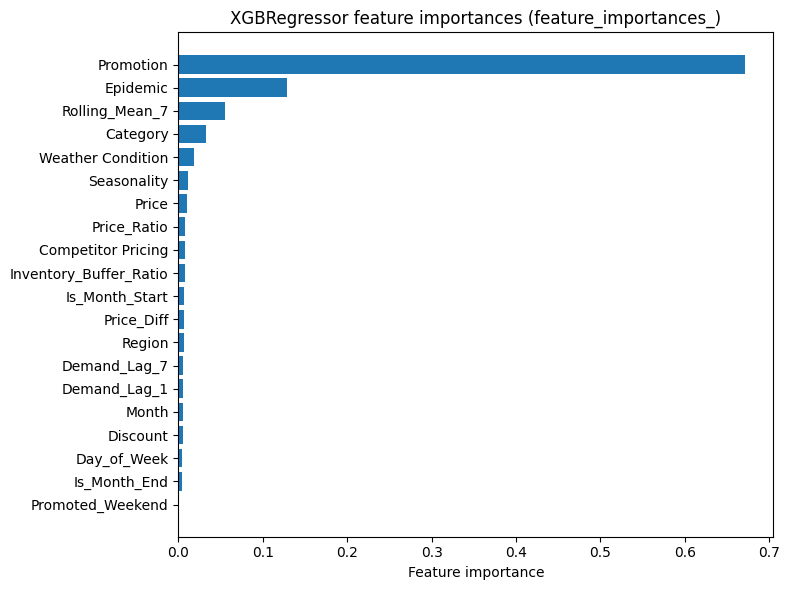

In [121]:
import matplotlib.pyplot as plt

# compute importances (aligned with x_train columns)
importances = pd.Series(model.feature_importances_, index=x_train.columns).sort_values(ascending=False)

# display as dataframe
fi_df = importances.reset_index().rename(columns={'index':'feature', 0:'importance'})
fi_df

# plot top 20
plt.figure(figsize=(8,6))
plt.barh(importances.head(20)[::-1].index, importances.head(20)[::-1].values)
plt.xlabel('Feature importance')
plt.title('XGBRegressor feature importances (feature_importances_)')
plt.tight_layout()
plt.show()